## Simple Bayesian Linear Regression for Media Mix Modeling (No Adstock)

In [2]:
# ----------------------------------------
# 📊 Simple Bayesian Linear Regression for Media Mix Modeling (No Adstock)
# ----------------------------------------

import pymc as pm
import arviz as az
import pandas as pd
import numpy as np

# ----------------------------------------
# Step 1: Simulate Media Spend and Sales Data
# ----------------------------------------

# Data in lakhs (TV & digital spend, and total sales)
data = {
    "sales":   [100, 120, 130, 125, 150, 160],  # observed weekly sales (lakhs)
    "tv":      [10, 15, 20, 15, 25, 30],        # TV media spend (lakhs)
    "digital": [5, 7, 10, 8, 12, 14]            # Digital media spend (lakhs)
}

df = pd.DataFrame(data)  # Create DataFrame for modeling

In [3]:
# ----------------------------------------
# Step 2: Define PyMC Bayesian Linear Model
# ----------------------------------------

with pm.Model() as model:

    # ---- Priors ----
    # These reflect our beliefs *before* seeing the data
    alpha = pm.Normal("intercept", mu=0, sigma=10)             # Intercept (baseline sales)
    beta_tv = pm.Normal("beta_tv", mu=0.2, sigma=0.1)           # TV channel effectiveness
    beta_digital = pm.Normal("beta_digital", mu=0.3, sigma=0.1) # Digital channel effectiveness
    sigma = pm.HalfNormal("sigma", sigma=10)                   # Standard deviation (uncertainty)

    # ---- Linear Model ----
    # Sales are modeled as a linear combination of TV and digital spend
    mu = alpha + beta_tv * df["tv"] + beta_digital * df["digital"]

    # ---- Likelihood ----
    # Observed sales are normally distributed around expected sales (mu)
    y_obs = pm.Normal("sales", mu=mu, sigma=sigma, observed=df["sales"])


Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


array([<Axes: title={'center': 'beta_tv'}>,
       <Axes: title={'center': 'beta_digital'}>], dtype=object)

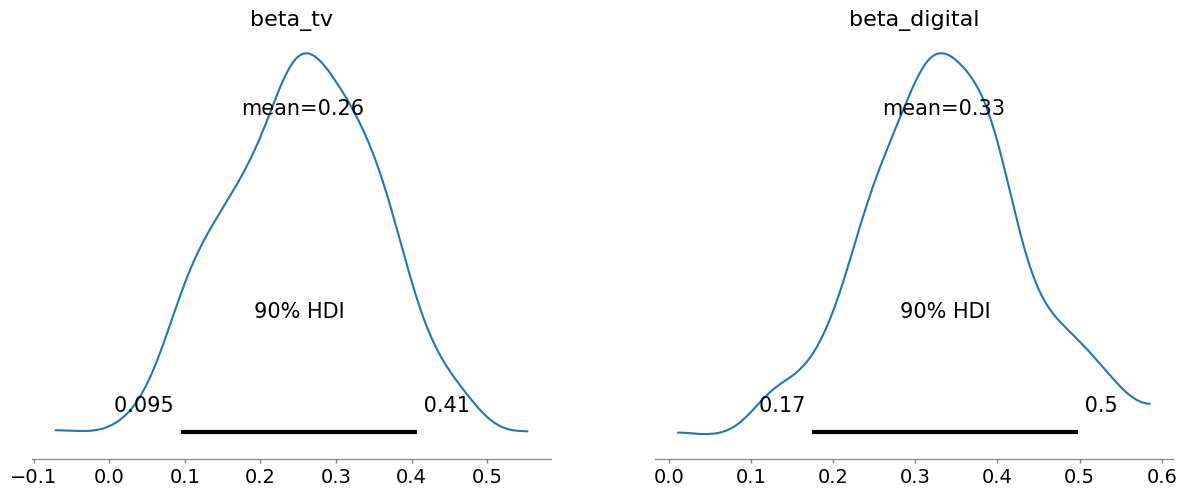

In [4]:
import pymc as pm

# ----------------------------------------
# Step 3: Posterior Inference using MCMC
# ----------------------------------------

with model:
    trace = pm.sample(
        draws=200,
        tune=100,
        target_accept=0.9,
        random_seed=42
    )

# ----------------------------------------
# Step 4: Visualize Posterior Distributions
# ----------------------------------------

# ArviZ provides a clean visual summary of posterior parameter estimates
az.plot_posterior(trace,
                  var_names=["beta_tv", "beta_digital"],
                  hdi_prob=0.9)  # Show 90% highest density intervals (credible intervals)

## Adstock in PyMC – Step-by-Step

In [7]:
# Define a geometric adstock function in NumPy (for simulation or explanation)
def geometric_adstock(x, theta):
    """
    Geometric Adstock: Applies geometric decay to a time series.
    - θ (theta) is the decay rate: newer impressions have more impact.
    - Pros: Simple, interpretable, computationally efficient.
    """
    result = np.zeros_like(x)
    for t in range(len(x)):
        for i in range(t + 1):
            result[t] += x[t - i] * theta**i  # Decay previous values
    return result


# ----------------------------------------
# Step 1: Import Libraries and Prepare Data
# ----------------------------------------

# import pymc as pm
# import numpy as np
# import pandas as pd
import pytensor.tensor as at
# import arviz as az

# Simulated marketing dataset with weekly sales and media spend
df = pd.DataFrame({
    "sales":    [100, 120, 130, 125, 150, 160],   # target variable
    "tv":       [10, 15, 20, 15, 25, 30],         # TV spend
    "digital":  [5, 7, 10, 8, 12, 14]             # Digital spend
})



In [8]:

# ----------------------------------------
# Step 2: Define Adstock Transformation in PyTensor (Aesara-compatible)
# ----------------------------------------

def adstock_aesara(x, theta):
    """
    Geometric Adstock in PyTensor for use inside PyMC models.
    - Handles symbolic differentiation.
    - Applies decay to each time step using theta.
    """
    result = at.zeros_like(x)
    for i in range(x.shape[0]):
        # Reverse cumulative weighted sum with decay factor
        result = at.set_subtensor(result[i], at.sum(x[:i+1][::-1] * theta**at.arange(i+1)))
    return result

In [9]:
# ----------------------------------------
# Step 3: Define PyMC Bayesian Model Using Adstock
# ----------------------------------------

with pm.Model() as model:

    # Prior for adstock decay (between 0 and 1 using Beta distribution)
    theta_tv = pm.Beta("theta_tv", alpha=2, beta=2)           # Decay for TV
    theta_digital = pm.Beta("theta_digital", alpha=2, beta=2) # Decay for Digital

    # Apply adstock transformation on media channels
    tv_adstocked = adstock_aesara(df["tv"].values.astype("float32"), theta_tv)
    digital_adstocked = adstock_aesara(df["digital"].values.astype("float32"), theta_digital)

    # Priors for regression coefficients
    alpha = pm.Normal("intercept", mu=0, sigma=10)            # Baseline sales
    beta_tv = pm.Normal("beta_tv", mu=0.2, sigma=0.1)         # Effect of TV spend
    beta_digital = pm.Normal("beta_digital", mu=0.3, sigma=0.1)  # Effect of Digital spend
    sigma = pm.HalfNormal("sigma", sigma=10)                  # Noise term

    # Linear combination of adstocked media and intercept
    mu = alpha + beta_tv * tv_adstocked + beta_digital * digital_adstocked

    # Likelihood: how the observed sales are generated
    y_obs = pm.Normal("sales", mu=mu, sigma=sigma, observed=df["sales"].values)

Output()

array([<Axes: title={'center': 'beta_tv'}>,
       <Axes: title={'center': 'beta_digital'}>,
       <Axes: title={'center': 'theta_tv'}>,
       <Axes: title={'center': 'theta_digital'}>], dtype=object)

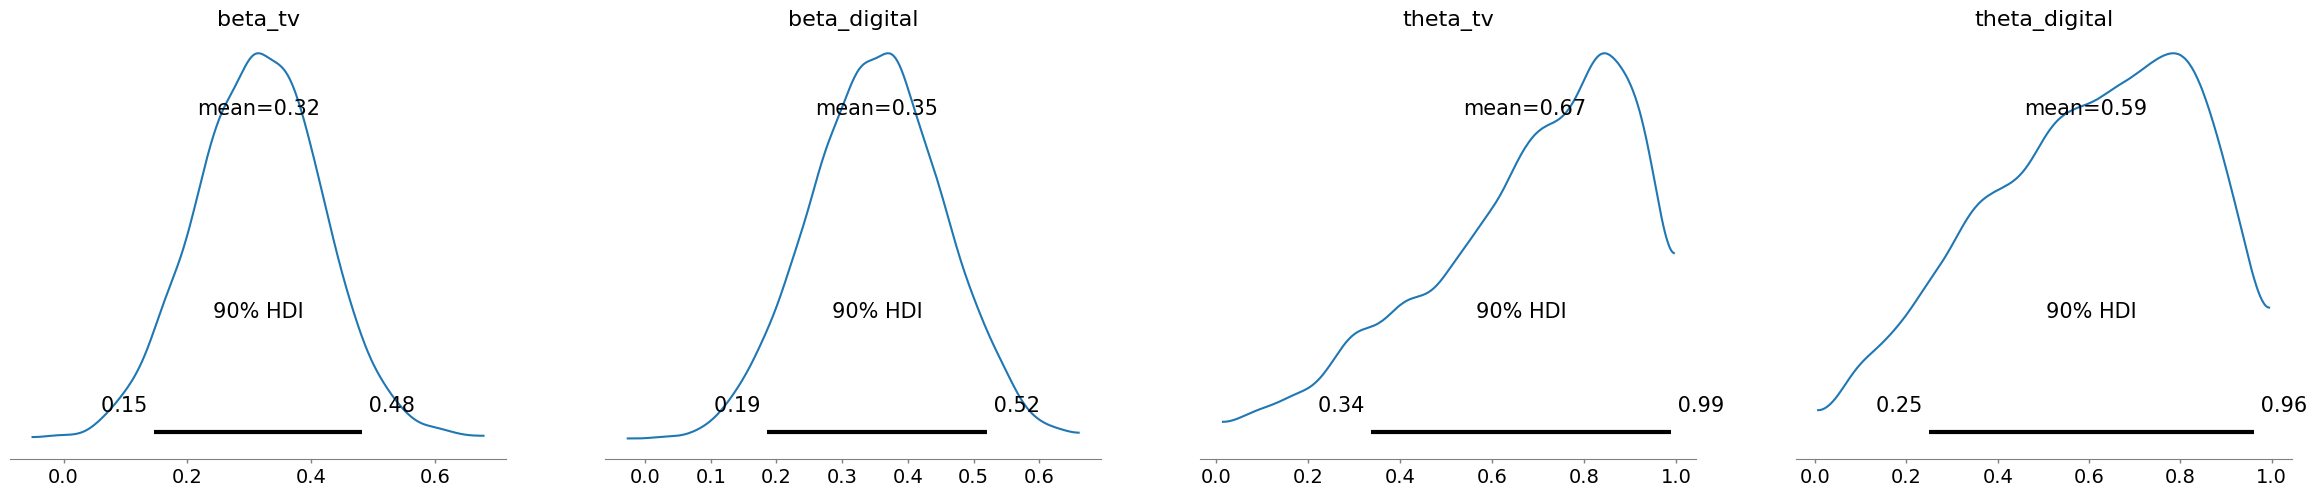

In [10]:
# ----------------------------------------
# Step 4: Run MCMC Sampling
# ----------------------------------------

with model:
    trace = pm.sample(2000,      # Number of posterior samples
                      tune=1000, # Burn-in period
                      target_accept=0.9,  # Prevent divergent samples
                      random_seed=42)    # Reproducibility


# ----------------------------------------
# Step 5: Visualize Posterior Distributions
# ----------------------------------------

# Plot the estimated distributions of the model parameters
az.plot_posterior(trace,
                  var_names=["beta_tv", "beta_digital", "theta_tv", "theta_digital"],
                  hdi_prob=0.9)  # Show 90% HDI (credible intervals)

## Adding Stauration effect with Adstock as well

In [11]:
# ----------------------------------------
# 🧪 Step 1: Imports and Simulated Data
# ----------------------------------------

# import pymc as pm
# import numpy as np
# import pandas as pd
# import pytensor.tensor as at
# import arviz as az

# Small mock dataset to illustrate MMM with media and sales
df = pd.DataFrame({
    "sales":    [100, 120, 130, 125, 150, 160],  # weekly sales (target variable)
    "tv":       [10, 15, 20, 15, 25, 30],        # TV spend per week
    "digital":  [5, 7, 10, 8, 12, 14]            # Digital spend per week
})


# ----------------------------------------
# 🚀 Step 2: Adstock + Saturation Function (Aesara compatible)
# ----------------------------------------

def adstock_saturation(x, theta, alpha):
    """
    Applies geometric adstock and log-saturation to input spend.

    - Adstock: captures delayed/lagged effect of media (e.g. recall over time).
    - Saturation: diminishing returns as spend increases (logarithmic effect).
    - `theta`: decay factor (0 to 1), controls memory decay.
    - `alpha`: saturation multiplier, scales the response curve.
    """
    result = at.zeros_like(x)
    for i in range(x.shape[0]):
        # Weighted cumulative sum with decay applied in reverse
        result = at.set_subtensor(
            result[i],
            at.sum(x[:i+1][::-1] * theta**at.arange(i+1))
        )
    return at.log1p(alpha * result)  # log(1 + α × adstocked)

In [12]:
# ----------------------------------------
# 📦 Step 3: Define PyMC Model with Adstock + Saturation
# ----------------------------------------

with pm.Model() as model:

    # ---- Adstock + Saturation Priors ----
    theta_tv = pm.Beta("theta_tv", alpha=2, beta=2)              # TV adstock decay
    alpha_tv = pm.HalfNormal("alpha_tv", sigma=1)                # TV saturation effect

    theta_digital = pm.Beta("theta_digital", alpha=2, beta=2)    # Digital adstock decay
    alpha_digital = pm.HalfNormal("alpha_digital", sigma=1)      # Digital saturation effect

    # ---- Apply transformation ----
    tv_transformed = adstock_saturation(df["tv"].values.astype("float32"), theta_tv, alpha_tv)
    digital_transformed = adstock_saturation(df["digital"].values.astype("float32"), theta_digital, alpha_digital)

    # ---- Regression Coefficients ----
    intercept = pm.Normal("intercept", mu=0, sigma=10)             # Baseline sales
    beta_tv = pm.Normal("beta_tv", mu=0.3, sigma=0.1)              # TV effectiveness
    beta_digital = pm.Normal("beta_digital", mu=0.3, sigma=0.1)    # Digital effectiveness
    sigma = pm.HalfNormal("sigma", sigma=10)                       # Residual noise

    # ---- Expected sales (Linear model) ----
    mu = intercept + beta_tv * tv_transformed + beta_digital * digital_transformed

    # ---- Likelihood ----
    y_obs = pm.Normal("sales", mu=mu, sigma=sigma, observed=df["sales"].values)

Output()

array([[<Axes: title={'center': 'beta_tv'}>,
        <Axes: title={'center': 'beta_digital'}>,
        <Axes: title={'center': 'theta_tv'}>],
       [<Axes: title={'center': 'theta_digital'}>,
        <Axes: title={'center': 'alpha_tv'}>,
        <Axes: title={'center': 'alpha_digital'}>]], dtype=object)

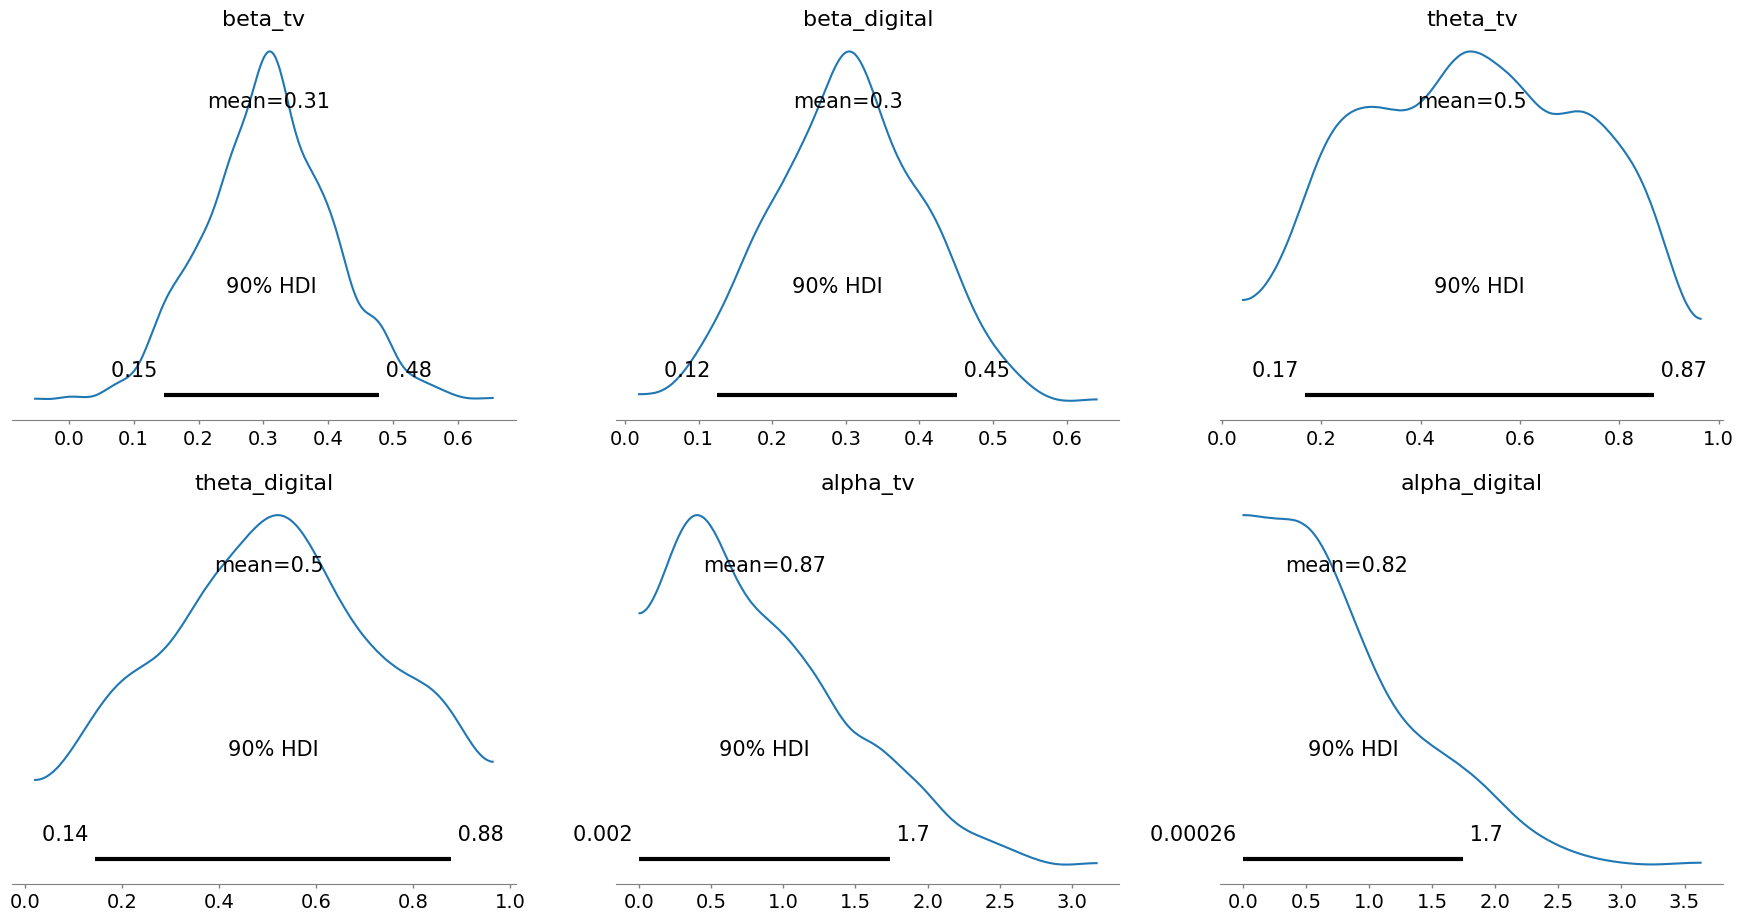

In [13]:
# ----------------------------------------
# 🔁 Step 4: Run MCMC Sampling
# ----------------------------------------

with model:
    trace = pm.sample(400,         # Posterior samples
                      tune=200,    # Warm-up
                      target_accept=0.9,  # Higher value = fewer divergences
                      random_seed=42)     # Reproducibility


# ----------------------------------------
# 📈 Step 5: Visualize Posterior Distributions
# ----------------------------------------

az.plot_posterior(
    trace,
    var_names=[
        "beta_tv", "beta_digital",         # Channel effectiveness
        "theta_tv", "theta_digital",       # Adstock memory
        "alpha_tv", "alpha_digital"        # Saturation impact
    ],
    hdi_prob=0.9  # 90% highest density interval (credible range)
)